WEATHER FORECASTING USING LSTMs

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

In [ ]:
file_path = 'https://raw.githubusercontent.com/Rakshith2605/weather-lstm-gru/main/data/NN1.csv'
df = pd.read_csv(file_path)

<ipython-input-35-7ff4881bb379>:2: DtypeWarning: Columns (52,61,90) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [ ]:
df.columns

Index(['STATION', 'DATE', 'SOURCE', 'LATITUDE', 'LONGITUDE', 'ELEVATION',
       'NAME', 'REPORT_TYPE', 'CALL_SIGN', 'QUALITY_CONTROL',
       ...
       'OC1', 'OD1', 'OE1', 'OE2', 'OE3', 'RH1', 'RH2', 'RH3', 'REM', 'EQD'],
      dtype='object', length=101)

In [ ]:
df.head()

,STATION,DATE,SOURCE,LATITUDE,LONGITUDE,ELEVATION,NAME,REPORT_TYPE,CALL_SIGN,QUALITY_CONTROL,...,OC1,OD1,OE1,OE2,OE3,RH1,RH2,RH3,REM,EQD
0,72509014739,2019-01-01T00:00:00,4,42.3606,-71.0097,3.7,"BOSTON, MA US",FM-12,99999,V020,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SYN09272509 11566 81609 10056 21017 30239 4024...,NaN
1,72509014739,2019-01-01T00:54:00,7,42.3606,-71.0097,3.7,"BOSTON, MA US",FM-15,KBOS,V030,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MET11912/31/18 19:54:01 METAR KBOS 010054Z 140...,NaN
2,72509014739,2019-01-01T01:54:00,7,42.3606,-71.0097,3.7,"BOSTON, MA US",FM-15,KBOS,V030,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MET12112/31/18 20:54:01 METAR KBOS 010154Z 130...,NaN
3,72509014739,2019-01-01T02:38:00,7,42.3606,-71.0097,3.7,"BOSTON, MA US",FM-16,KBOS,V030,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MET12212/31/18 21:38:01 SPECI KBOS 010238Z 150...,NaN
4,72509014739,2019-01-01T02:54:00,7,42.3606,-71.0097,3.7,"BOSTON, MA US",FM-15,KBOS,V030,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MET14512/31/18 21:54:01 METAR KBOS 010254Z 140...,Q01 00308PRCP03


In [ ]:
df.shape

(14091, 101)

In [ ]:
miss = df.isnull().sum()

In [ ]:
threshold = 3000
df = df.loc[:, miss <= threshold]

In [ ]:
df.shape

(14091, 21)

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.dtypes

,0
STATION,int64
DATE,object
SOURCE,int64
LATITUDE,float64
LONGITUDE,float64
ELEVATION,float64
NAME,object
REPORT_TYPE,object
CALL_SIGN,object
QUALITY_CONTROL,object


In [ ]:
df.drop(['NAME', 'ELEVATION','LATITUDE', 'LONGITUDE','ELEVATION','REM','GE1'], axis=1, inplace=True)

In [ ]:
df.isnull().sum()

,0
STATION,0
DATE,0
SOURCE,0
REPORT_TYPE,0
CALL_SIGN,0
QUALITY_CONTROL,0
WND,0
CIG,0
VIS,0
TMP,0


In [ ]:
df.head()

,STATION,DATE,SOURCE,REPORT_TYPE,CALL_SIGN,QUALITY_CONTROL,WND,CIG,VIS,TMP,DEW,SLP,GA1,GF1,MA1
0,72509014739,2019-01-01T00:00:00,4,FM-12,99999,V020,"160,1,N,0046,1","99999,9,9,N","016000,1,9,9","+0056,1","-0017,1","10248,1","99,9,+00800,1,99,9","08,99,1,99,9,99,9,00800,1,99,9,99,9","99999,9,10239,1"
1,72509014739,2019-01-01T00:54:00,7,FM-15,KBOS,V030,"140,5,N,0057,5","01006,5,M,N","016093,5,N,5","+0039,5","+0000,5","10233,5","07,5,+01006,5,99,9","99,99,9,99,9,99,9,01006,1,99,9,99,9","10234,5,10223,5"
2,72509014739,2019-01-01T01:54:00,7,FM-15,KBOS,V030,"130,5,N,0062,5","01372,5,M,N","009656,5,N,5","+0033,5","+0011,5","10208,5","07,5,+01372,5,99,9","99,99,9,99,9,99,9,01372,1,99,9,99,9","10210,5,10199,5"
3,72509014739,2019-01-01T02:38:00,7,FM-16,KBOS,V030,"150,5,N,0057,5","00823,5,M,N","009656,5,N,5","+0028,5","+0011,5","99999,9","02,5,+00518,5,99,9","99,99,9,99,9,99,9,00518,1,99,9,99,9","10203,5,10192,5"
4,72509014739,2019-01-01T02:54:00,7,FM-15,KBOS,V030,"140,5,N,0067,5","00488,5,M,N","011265,5,N,5","+0028,5","+0011,5","10187,5","07,5,+00488,5,99,9","99,99,9,99,9,99,9,00488,1,99,9,99,9","10190,5,10179,5"


In [ ]:
df.head()

,STATION,DATE,SOURCE,REPORT_TYPE,CALL_SIGN,QUALITY_CONTROL,WND,CIG,VIS,TMP,DEW,SLP,GA1,GF1,MA1
0,72509014739,2019-01-01T00:00:00,4,FM-12,99999,V020,"160,1,N,0046,1","99999,9,9,N","016000,1,9,9","+0056,1","-0017,1","10248,1","99,9,+00800,1,99,9","08,99,1,99,9,99,9,00800,1,99,9,99,9","99999,9,10239,1"
1,72509014739,2019-01-01T00:54:00,7,FM-15,KBOS,V030,"140,5,N,0057,5","01006,5,M,N","016093,5,N,5","+0039,5","+0000,5","10233,5","07,5,+01006,5,99,9","99,99,9,99,9,99,9,01006,1,99,9,99,9","10234,5,10223,5"
2,72509014739,2019-01-01T01:54:00,7,FM-15,KBOS,V030,"130,5,N,0062,5","01372,5,M,N","009656,5,N,5","+0033,5","+0011,5","10208,5","07,5,+01372,5,99,9","99,99,9,99,9,99,9,01372,1,99,9,99,9","10210,5,10199,5"
3,72509014739,2019-01-01T02:38:00,7,FM-16,KBOS,V030,"150,5,N,0057,5","00823,5,M,N","009656,5,N,5","+0028,5","+0011,5","99999,9","02,5,+00518,5,99,9","99,99,9,99,9,99,9,00518,1,99,9,99,9","10203,5,10192,5"
4,72509014739,2019-01-01T02:54:00,7,FM-15,KBOS,V030,"140,5,N,0067,5","00488,5,M,N","011265,5,N,5","+0028,5","+0011,5","10187,5","07,5,+00488,5,99,9","99,99,9,99,9,99,9,00488,1,99,9,99,9","10190,5,10179,5"


In [ ]:
def extract_wind_speed(wnd_value):
    # Split the string by commas
    parts = wnd_value.split(',')
    # The wind speed is in the 4th part (index 3)
    wind_speed = int(parts[3])  # Convert to integer
    return wind_speed

# Apply the function to the "WND" column
df['WND'] = df['WND'].apply(extract_wind_speed)

In [ ]:
def extract_dew_point(dew_value):
    # Split the string by comma
    parts = dew_value.split(',')
    # The dew point temperature is in the first part
    dew_point_tenths = int(parts[0])  # Convert to integer
    # Convert from tenths of degrees Celsius to degrees Celsius
    dew_point_celsius = dew_point_tenths / 10
    return dew_point_celsius

# Apply the function to the "DEW" column
df['DEW'] = df['DEW'].apply(extract_dew_point)

In [ ]:
def extract_slp(slp_value):
    # Split the string by comma
    parts = slp_value.split(',')
    # The pressure value is in the first part
    slp_tenths = int(parts[0])  # Convert to integer
    # Convert from tenths of hPa to hPa
    slp_hpa = slp_tenths / 10
    return slp_hpa

# Apply the function to the "SLP" column
df['SLP'] = df['SLP'].apply(extract_slp)

In [ ]:
def extract_altitude(ga1_value):
    # Split the string by commas
    parts = ga1_value.split(',')
    # Extract the altitude part (3rd part)
    altitude = int(parts[2])  # Convert to integer
    return altitude

# Apply the function to the "GA1" column
df['GA1'] = df['GA1'].apply(extract_altitude)

In [ ]:
def extract_ceiling_height(cig_value):
    # Split the string by commas
    parts = cig_value.split(',')
    # Extract the ceiling height part (1st part)
    ceiling_height = int(parts[0])
    # Return 'No ceiling' for 99999; otherwise, return height in feet
    return "No ceiling" if ceiling_height == 99999 else ceiling_height

# Apply the function to the "CIG" column
df['CIG'] = df['CIG'].apply(extract_ceiling_height)

In [ ]:
def extract_visibility(vis_value):
    # Split the string by commas
    parts = vis_value.split(',')
    # Extract the visibility part (1st part)
    visibility_meters = int(parts[0])
    # Convert from meters to kilometers
    visibility_km = visibility_meters / 1000
    return visibility_km
df['VIS'] = df['VIS'].apply(extract_visibility)

In [ ]:
def extract_frost_measurement(gf1_value):
    # Split the string by commas
    parts = gf1_value.split(',')
    # Extract the measurement value (8th part, index 7)
    measurement = int(parts[7])
    # Return None if the value is a placeholder (e.g., 99999)
    return measurement if measurement != 99999 else None

# Apply the function to the "GF1" column
df['GF1'] = df['GF1'].apply(extract_frost_measurement)

In [ ]:
def extract_pressure(ma1_value):
    # Split the string by commas
    parts = ma1_value.split(',')
    # Extract the measurements (1st and 3rd fields)
    measurement_1 = int(parts[0]) if int(parts[0]) != 99999 else None
    measurement_2 = int(parts[2]) if int(parts[2]) != 99999 else None
    # Convert to hPa if not None
    measurement_1 = measurement_1 / 10 if measurement_1 is not None else None
    measurement_2 = measurement_2 / 10 if measurement_2 is not None else None
    return measurement_1, measurement_2

# Apply the function to the "MA1" column
df[['MA1','MA1']] = df['MA1'].apply(
    lambda x: pd.Series(extract_pressure(x))
)

In [ ]:
df['DATE'] = pd.to_datetime(df['DATE'])

In [ ]:
df

,STATION,DATE,SOURCE,REPORT_TYPE,CALL_SIGN,QUALITY_CONTROL,WND,CIG,VIS,TMP,DEW,SLP,GA1,GF1,MA1
0,72509014739,2019-01-01 00:00:00,4,FM-12,99999,V020,46,No ceiling,16.000,"+0056,1",-1.7,1024.8,800,800.0,1023.9
1,72509014739,2019-01-01 00:54:00,7,FM-15,KBOS,V030,57,1006,16.093,"+0039,5",0.0,1023.3,1006,1006.0,1022.3
2,72509014739,2019-01-01 01:54:00,7,FM-15,KBOS,V030,62,1372,9.656,"+0033,5",1.1,1020.8,1372,1372.0,1019.9
3,72509014739,2019-01-01 02:38:00,7,FM-16,KBOS,V030,57,823,9.656,"+0028,5",1.1,9999.9,518,518.0,1019.2
4,72509014739,2019-01-01 02:54:00,7,FM-15,KBOS,V030,67,488,11.265,"+0028,5",1.1,1018.7,488,488.0,1017.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14086,72509014739,2019-12-31 21:00:00,4,FM-12,99999,V020,26,No ceiling,16.000,"+0033,1",0.6,1000.9,150,150.0,1000.3
14087,72509014739,2019-12-31 21:54:00,7,FM-15,KBOS,V030,41,213,16.093,"+0033,5",0.6,1000.9,213,213.0,999.9
14088,72509014739,2019-12-31 22:54:00,7,FM-15,KBOS,V030,36,488,16.093,"+0033,5",0.6,1001.2,274,274.0,1000.3
14089,72509014739,2019-12-31 23:44:00,7,FM-16,KBOS,V030,31,366,16.093,"+0039,5",0.6,9999.9,366,366.0,1000.3


In [ ]:
df['TMP'] = df['TMP'].str.replace(',', '.').astype(float)

# Drop the "+" if needed (Optional)
df['TMP'] = df['TMP'].apply(lambda x: x if not str(x).startswith('+') else float(str(x).lstrip('+')))



In [ ]:
df.columns


Index(['STATION', 'DATE', 'SOURCE', 'REPORT_TYPE', 'CALL_SIGN',
       'QUALITY_CONTROL', 'WND', 'CIG', 'VIS', 'TMP', 'DEW', 'SLP', 'GA1',
       'GF1', 'MA1'],
      dtype='object')

In [ ]:
df['TMP']

,TMP
0,56.1
1,39.5
2,33.5
3,28.5
4,28.5
...,...
14086,33.1
14087,33.5
14088,33.5
14089,39.5


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 100))
df["TMP"] = scaler.fit_transform(df["TMP"].values.reshape(-1, 1))

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df["DATE"],
        y=df["TMP"],
        mode='lines+markers',
        name='Temperature',
        line=dict(color='#1f77b4'),
        hovertemplate='<b>Date</b>: %{x}<br>' +
                      '<b>Temperature</b>: %{y:.1f}°F<br>'
    )
)

fig.update_layout(
    title='Temperature Variation Over Time',
    title_x=0.5,
    xaxis=dict(
        title='Date',
        rangeslider=dict(visible=True)
    ),
    yaxis=dict(title='Temperature (°F)'),
    hovermode='x unified',
    template='plotly_white',
    height=800,  # Increased height
    width=1200   # Specified width
)

# Add range selector buttons
fig.update_xaxes(
    rangeselector=dict(
        buttons=list([
            dict(count=1, label="1m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(step="all", label="All")
        ])
    )
)

fig.show()

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df["DATE"],
        y=df["WND"],
        mode='lines+markers',
        name='Wind Speed',
        line=dict(color='#E41B17', width=2),
        marker=dict(size=6),
        hovertemplate='<b>Date</b>: %{x}<br>' +
                      '<b>Wind Speed</b>: %{y:.2f}<br>'
    )
)

fig.update_layout(
    title={
        'text': 'Wind Speed Variation Over Time',
        'x': 0.5,
        'font': {'size': 24}
    },
    xaxis=dict(
        title='Date',
        rangeslider=dict(visible=True),
        rangeselector=dict(
            buttons=list([
                dict(count=1, label="1m", step="month", stepmode="backward"),
                dict(count=6, label="6m", step="month", stepmode="backward"),
                dict(count=1, label="1y", step="year", stepmode="backward"),
                dict(step="all", label="All")
            ])
        )
    ),
    yaxis=dict(
        title='Wind Speed',
        gridcolor='rgba(128, 128, 128, 0.2)',
        zeroline=False,
        range=[0, 300]  # Set y-axis range to relevant values
    ),
    hovermode='x unified',
    template='plotly_white',
    height=800,
    width=1200,
    showlegend=True
)

# Add range slider
fig.update_xaxes(rangeslider_visible=True)

fig.show()

In [ ]:
df[['DATE','TMP']]

,DATE,TMP
0,2019-01-01 00:00:00,40.351562
1,2019-01-01 00:54:00,37.109375
2,2019-01-01 01:54:00,35.937500
3,2019-01-01 02:38:00,34.960938
4,2019-01-01 02:54:00,34.960938
...,...,...
14086,2019-12-31 21:00:00,35.859375
14087,2019-12-31 21:54:00,35.937500
14088,2019-12-31 22:54:00,35.937500
14089,2019-12-31 23:44:00,37.109375


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
df['TMP'] = scaler.fit_transform(df[['TMP']])

In [ ]:
df['DATE'] = pd.to_datetime(df['DATE'])
df.set_index('DATE', inplace=True)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - loss: 0.0554 - mae: 0.1662 - val_loss: 0.0121 - val_mae: 0.0991
Epoch 2/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 0.0131 - mae: 0.0785 - val_loss: 0.0162 - val_mae: 0.1193
Epoch 3/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - loss: 0.0127 - mae: 0.0745 - val_loss: 0.0201 - val_mae: 0.1348
Epoch 4/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.0114 - mae: 0.0691 - val_loss: 0.0138 - val_mae: 0.1108
Epoch 5/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.0114 - mae: 0.0694 - val_loss: 0.0154 - val_mae: 0.1183
Epoch 6/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 0.0110 - mae: 0.0670 - val_loss: 0.0163 - val_mae: 0.1225
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


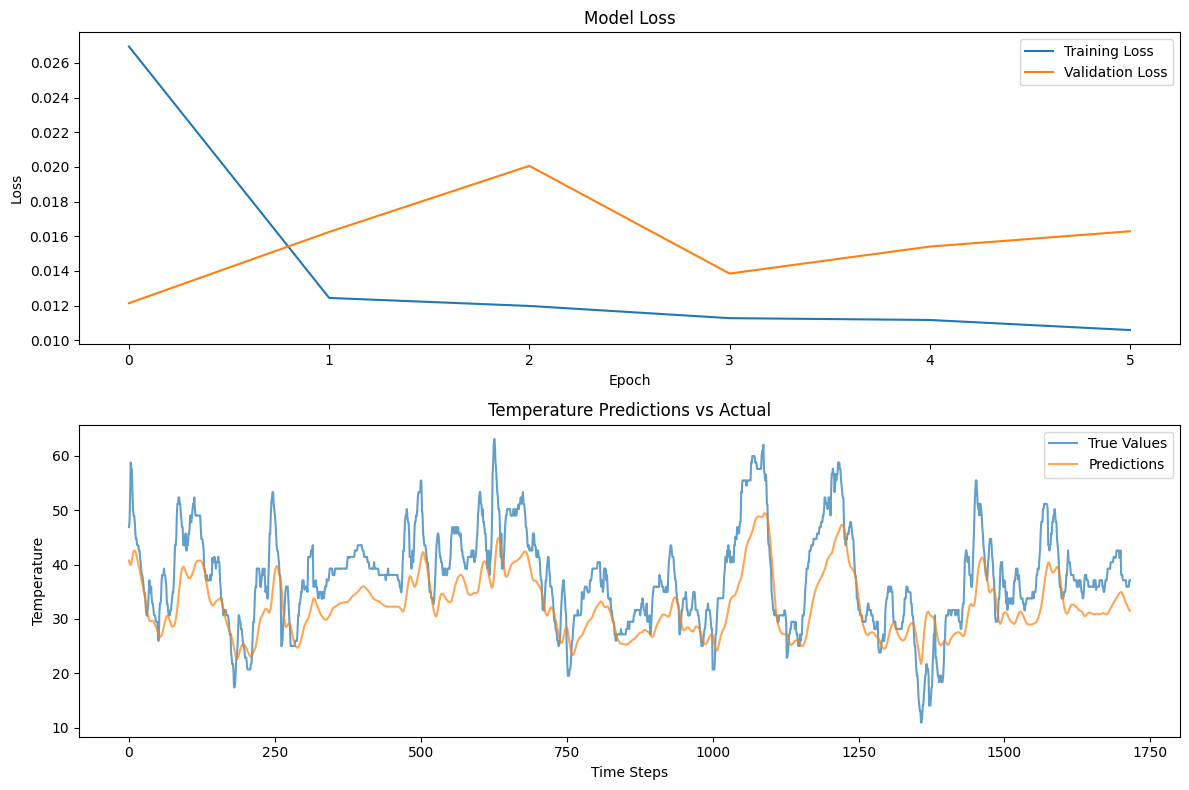


Test Set Metrics:
MSE: 52.55
RMSE: 7.25
MAE: 6.09
R2 Score: 0.31


In [ ]:
def create_sequences(data, sequence_length):
    sequences = []
    labels = []
    for i in range(len(data) - sequence_length):
        seq = data[i:i + sequence_length]
        label = data[i + sequence_length]
        sequences.append(seq)
        labels.append(label)
    return np.array(sequences), np.array(labels)

# Create sequences
sequence_length = 24  # 24 hours of data
sequences, labels = create_sequences(df['TMP'].values, sequence_length)

# Split into train, validation, and test sets
train_size = int(0.7 * len(sequences))
val_size = int(0.15 * len(sequences))
test_size = len(sequences) - train_size - val_size

X_train = sequences[:train_size]
y_train = labels[:train_size]
X_val = sequences[train_size:train_size+val_size]
y_val = labels[train_size:train_size+val_size]
X_test = sequences[train_size+val_size:]
y_test = labels[train_size+val_size:]

# Reshape data for LSTM (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Build the LSTM model with dropout for regularization
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(sequence_length, 1),
         dropout=0.2, recurrent_dropout=0.2),
    LSTM(32, dropout=0.2, recurrent_dropout=0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

# Compile with early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

# Make predictions
train_predictions = model.predict(X_train)
val_predictions = model.predict(X_val)
test_predictions = model.predict(X_test)

# Inverse transform predictions and actual values
train_predictions = scaler.inverse_transform(train_predictions)
val_predictions = scaler.inverse_transform(val_predictions)
test_predictions = scaler.inverse_transform(test_predictions)
y_train_orig = scaler.inverse_transform(y_train.reshape(-1, 1))
y_val_orig = scaler.inverse_transform(y_val.reshape(-1, 1))
y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot training history
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot predictions vs actual
plt.subplot(2, 1, 2)
plt.plot(y_test_orig, label='True Values', alpha=0.7)
plt.plot(test_predictions, label='Predictions', alpha=0.7)
plt.title('Temperature Predictions vs Actual')
plt.xlabel('Time Steps')
plt.ylabel('Temperature')
plt.legend()
plt.tight_layout()
plt.show()

# Print evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\nTest Set Metrics:")
print(f"MSE: {mean_squared_error(y_test_orig, test_predictions):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_orig, test_predictions)):.2f}")
print(f"MAE: {mean_absolute_error(y_test_orig, test_predictions):.2f}")
print(f"R2 Score: {r2_score(y_test_orig, test_predictions):.2f}")

In [ ]:
model.save('lstm_model.h5')
print("Model saved as 'lstm_model.h5'")

Model saved as 'lstm_model.h5'


In [ ]:
df.columns


Index(['STATION', 'SOURCE', 'REPORT_TYPE', 'CALL_SIGN', 'QUALITY_CONTROL',
       'WND', 'CIG', 'VIS', 'TMP', 'DEW', 'SLP', 'GA1', 'GF1', 'MA1', 'Month',
       'Year'],
      dtype='object')

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - loss: 101.2223 - mae: 8.0631 - val_loss: 1.9235 - val_mae: 0.9853
Epoch 2/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 27.7130 - mae: 3.1471 - val_loss: 3.5962 - val_mae: 1.6098
Epoch 3/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - loss: 26.3400 - mae: 2.9070 - val_loss: 5.1121 - val_mae: 2.0396
Epoch 4/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - loss: 25.3412 - mae: 2.7434 - val_loss: 5.3511 - val_mae: 2.0973
Epoch 5/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 26.8804 - mae: 2.7588 - val_loss: 2.8849 - val_mae: 1.5099
Epoch 6/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 24.1955 - mae: 2.5476 - val_loss: 4.8822 - val_mae: 1.9874
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


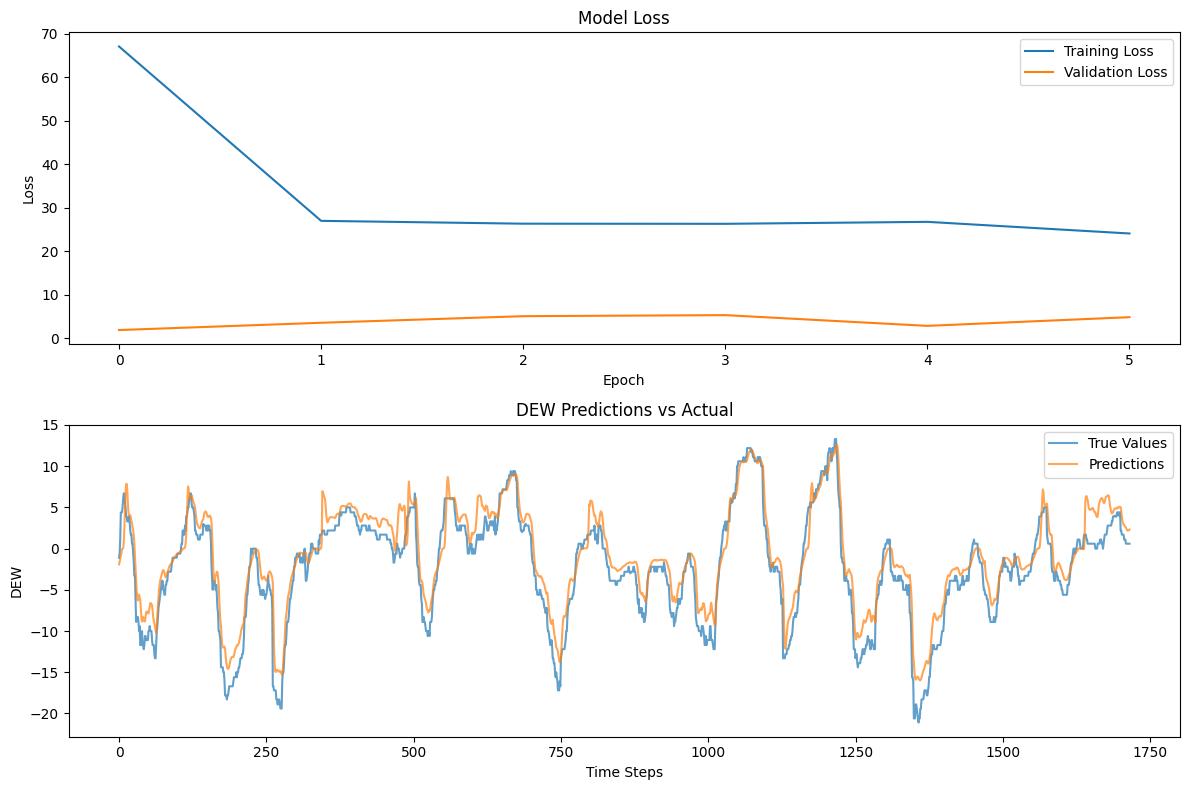


Test Set Metrics:
MSE: 5.50
RMSE: 2.35
MAE: 1.91
R2 Score: 0.88


In [ ]:
def create_sequences(data, sequence_length):
    sequences = []
    labels = []
    for i in range(len(data) - sequence_length):
        seq = data[i:i + sequence_length]
        label = data[i + sequence_length]
        sequences.append(seq)
        labels.append(label)
    return np.array(sequences), np.array(labels)

# Create sequences
sequence_length = 24  # 24 hours of data
sequences, labels = create_sequences(df['DEW'].values, sequence_length)

# Split into train, validation, and test sets
train_size = int(0.7 * len(sequences))
val_size = int(0.15 * len(sequences))
test_size = len(sequences) - train_size - val_size

X_train = sequences[:train_size]
y_train = labels[:train_size]
X_val = sequences[train_size:train_size+val_size]
y_val = labels[train_size:train_size+val_size]
X_test = sequences[train_size+val_size:]
y_test = labels[train_size+val_size:]

# Reshape data for LSTM (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Build the LSTM model with dropout for regularization
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(sequence_length, 1),
         dropout=0.2, recurrent_dropout=0.2),
    LSTM(32, dropout=0.2, recurrent_dropout=0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

# Compile with early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

# Make predictions
train_predictions = model.predict(X_train)
val_predictions = model.predict(X_val)
test_predictions = model.predict(X_test)

# Inverse transform predictions and actual values
train_predictions = scaler.inverse_transform(train_predictions)
val_predictions = scaler.inverse_transform(val_predictions)
test_predictions = scaler.inverse_transform(test_predictions)
y_train_orig = scaler.inverse_transform(y_train.reshape(-1, 1))
y_val_orig = scaler.inverse_transform(y_val.reshape(-1, 1))
y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot training history
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot predictions vs actual
plt.subplot(2, 1, 2)
plt.plot(y_test_orig, label='True Values', alpha=0.7)
plt.plot(test_predictions, label='Predictions', alpha=0.7)
plt.title('DEW Predictions vs Actual')
plt.xlabel('Time Steps')
plt.ylabel('DEW')
plt.legend()
plt.tight_layout()
plt.show()

# Print evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\nTest Set Metrics:")
print(f"MSE: {mean_squared_error(y_test_orig, test_predictions):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_orig, test_predictions)):.2f}")
print(f"MAE: {mean_absolute_error(y_test_orig, test_predictions):.2f}")
print(f"R2 Score: {r2_score(y_test_orig, test_predictions):.2f}")

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



251/251 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - loss: 2672.8914 - mae: 39.4468 - val_loss: 872.5316 - val_mae: 21.9371
Epoch 2/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - loss: 3661.5798 - mae: 19.1140 - val_loss: 790.0795 - val_mae: 21.0751
Epoch 3/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - loss: 26443.9297 - mae: 19.0025 - val_loss: 459.5759 - val_mae: 14.4681
Epoch 4/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 42123.2578 - mae: 17.7014 - val_loss: 371.9934 - val_mae: 13.4985
Epoch 5/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 7514.6543 - mae: 13.2224 - val_loss: 360.2271 - val_mae: 13.7752
Epoch 6/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - loss: 5501.5483 - mae: 12.8229 - val_loss: 324.9919 - val_mae: 12.9655
Epoch 7/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 8880.0615 - mae: 12.9740 - val_loss: 296.2213 - val_mae: 12.9287
Epoch 8/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 5108.7183 - mae: 12.6213 - val_loss: 280.0631 - val_mae: 12.22

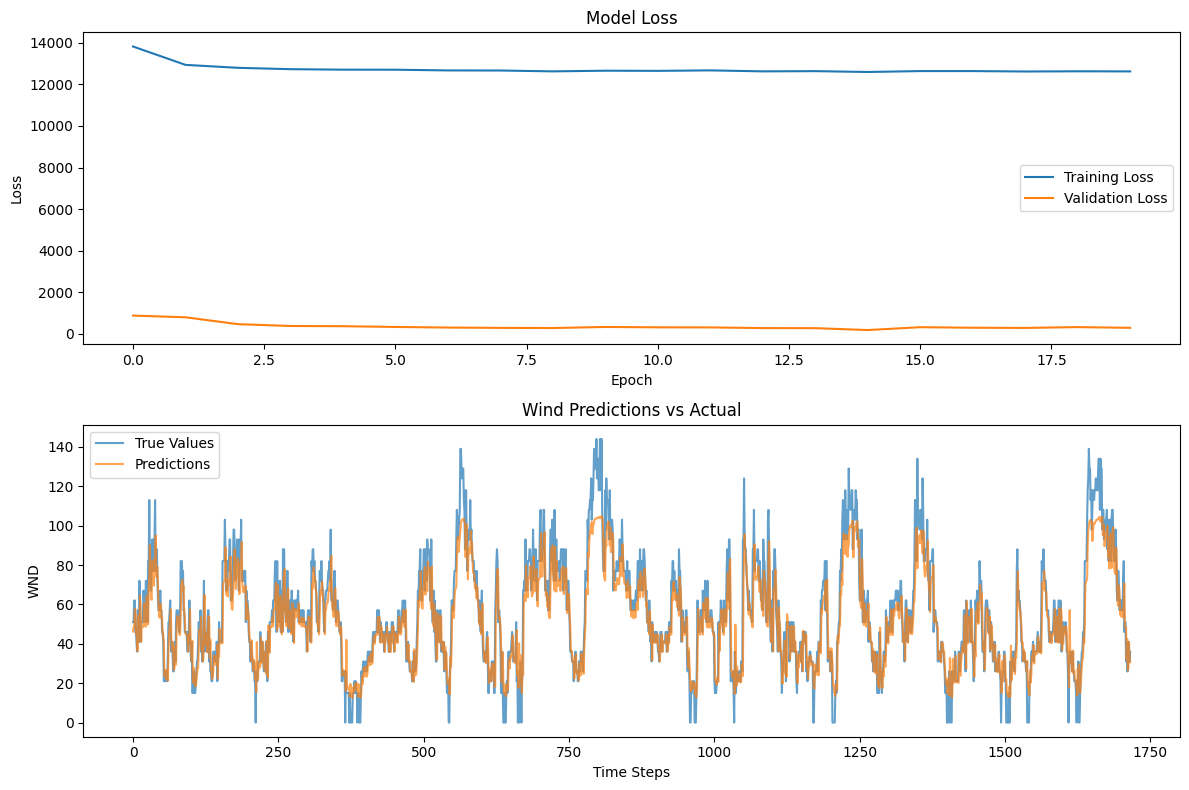


Test Set Metrics:
MSE: 164.67
RMSE: 12.83
MAE: 9.42
R2 Score: 0.79


In [ ]:
def create_sequences(data, sequence_length):
    sequences = []
    labels = []
    for i in range(len(data) - sequence_length):
        seq = data[i:i + sequence_length]
        label = data[i + sequence_length]
        sequences.append(seq)
        labels.append(label)
    return np.array(sequences), np.array(labels)

# Create sequences
sequence_length = 24  # 24 hours of data
sequences, labels = create_sequences(df['WND'].values, sequence_length)

# Split into train, validation, and test sets
train_size = int(0.7 * len(sequences))
val_size = int(0.15 * len(sequences))
test_size = len(sequences) - train_size - val_size

X_train = sequences[:train_size]
y_train = labels[:train_size]
X_val = sequences[train_size:train_size+val_size]
y_val = labels[train_size:train_size+val_size]
X_test = sequences[train_size+val_size:]
y_test = labels[train_size+val_size:]

# Reshape data for LSTM (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Build the LSTM model with dropout for regularization
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(sequence_length, 1),
         dropout=0.2, recurrent_dropout=0.2),
    LSTM(32, dropout=0.2, recurrent_dropout=0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

# Compile with early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

# Make predictions
train_predictions = model.predict(X_train)
val_predictions = model.predict(X_val)
test_predictions = model.predict(X_test)

# Inverse transform predictions and actual values
train_predictions = scaler.inverse_transform(train_predictions)
val_predictions = scaler.inverse_transform(val_predictions)
test_predictions = scaler.inverse_transform(test_predictions)
y_train_orig = scaler.inverse_transform(y_train.reshape(-1, 1))
y_val_orig = scaler.inverse_transform(y_val.reshape(-1, 1))
y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot training history
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot predictions vs actual
plt.subplot(2, 1, 2)
plt.plot(y_test_orig, label='True Values', alpha=0.7)
plt.plot(test_predictions, label='Predictions', alpha=0.7)
plt.title('Wind Predictions vs Actual')
plt.xlabel('Time Steps')
plt.ylabel('WND')
plt.legend()
plt.tight_layout()
plt.show()

# Print evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\nTest Set Metrics:")
print(f"MSE: {mean_squared_error(y_test_orig, test_predictions):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_orig, test_predictions)):.2f}")
print(f"MAE: {mean_absolute_error(y_test_orig, test_predictions):.2f}")
print(f"R2 Score: {r2_score(y_test_orig, test_predictions):.2f}")